#  Model Evaluation Notebook

**Description**

This notebook is used for model performance evaluation by calculating these metrics including IoU and Dice coefficient (F1-score) and model prediction visualization on the whole area. Furthermore, it also saves the false negative (FN) and false positive (FP) map from model prediction output for visual inspection.

**Input folder(s)/file(s)**

7 files
- Test image tiles folder (example: `../data/processed/tiles/test`)
- Public Urban Green Spaces (PUGS) ground truth (geojson file) (`dresden_pugs_gt.geojson`)
- Public Urban Green Spaces (PUGS) ground truth (raster) (`dresden_pugs_gt.geotiff`)
- Public Urban Green Spaces (PUGS) ground truth clipped to Dresden boundary (raster) (`clipped_dresden_pugs_gt.geotiff`)
- The best model checkpoint (example: `epoch=47-val_loss=0.18.ckpt`)
- Metrics file (CSV file) (`metrics.csv`)
- Sentinel-2 image stack with PUGS OSM binary mask and SDT (`stacked_sentinel2_dresden.geotiff`)

**Output folder(s)/file(s)**

2 folders and 3 files
- Output folder for prediction result visualization (example: `../reports/figure/gt_vs_pred/v0`)
- `fn_fp_maps` folder which contains the False Negative (FN) and False Positive (FP) area from each model prediction output
- Loss graph over Epochs (example: `loss_graph_v0.png`)
- Whole area prediction (example: `pred_v0.geotiff`)
- Whole area prediction (clipped to Dresden boundary) (example: `clipped_pred_v0.geotiff`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- 1_data_acquisition_osm.ipynb
- 1_data_acquisition_ground_truth.ipynb
- 1_data_acquisition_satellite_image.ipynb
- 2_data_processing_osm.ipynb
- 2_data_processing_ground_truth.ipynb
- 3_data_processing_satellite_image.ipynb
- 5_ground_truth_creation.ipynb
- 6_model_training.ipynb

**Note:** It does not require user to run `4_ground_truth_exploration.ipynb` notebook. The exploration notebook is created for understanding how each ground truth dataset complement each other and help author decide on which datasets will be used to create a final ground truth dataset.

In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

**Remarks**

The output shown in the notebook is run from this model experiment.

- **Input**: Sentinel-2 image and PUGS binary mask derived from OSM (input channels is 14 channels)
- **Version**: 1

More detail about model experiment setup can be found in [Model experiment setup](../models/README.md#model-experiment-setup)

# 1. Import libraries and load config

It can take up to 5-6 mins to complete this section.

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
import torchgeo
import torch
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import pandas as pd
import yaml
from rasterio.mask import mask
from shapely.geometry import mapping
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from pugs_detection.modeling.segmentation_task import CustomSegmentationTask
from pugs_detection.modeling.evaluation import generate_confusion_matrix
from pugs_detection.plots import (
    visualize_area,
    visualize_from_torchgeo_dataloader,
    visualize_predictions,
    plot_loss_graph,
)
from pugs_detection.dataset import PredictedImageDataset, create_dataset_split
from pugs_detection.utils import set_all_seeds, get_checkpoint_path
from pugs_detection.modeling.predict import predict_whole_area
from pugs_detection.raster import save_inference_map

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information when converting to a PROJ string from another format.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired.*",
    category=UserWarning,
)

In [4]:
# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# 2. Set seed for reproducibility

In [5]:
# Set seeds for reproducibility
seed = config["general"]["seed"]
set_all_seeds(seed)

Seed set to 42


In [6]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

# 3. Set variables

In [7]:
test_image_path = config["paths"]["test_image_path"]
label_path = config["paths"]["gt_vector_path"]

band_list_predict = config["data"]["band_list"]
num_channels = len(band_list_predict)

# Path to your checkpoint file
version = config["model"]["version"]
checkpoint_path = get_checkpoint_path(version)

metrics_path = config["paths"]["train_metrics_template"].format(version=version)
loss_graph_path = config["paths"]["loss_graph_template"].format(version=version)
dump_test_metrics_path = config["paths"]["test_metrics_template"].format(
    version=version
)

image_path_whole_area = config["paths"]["whole_image_path"]
clipped_image_path = config["paths"]["clipped_image_path"]
prediction_image_path = config["paths"]["whole_prediction_template"].format(
    version=version
)
clipped_prediction_image_path = config["paths"]["clipped_prediction_template"].format(
    version=version
)

# Ground Truth Data Paths
clipped_ground_truth_path = config["paths"]["clipped_gt_raster_path"]
ground_truth_path = config["paths"]["gt_raster_path"]

output_dir = config["paths"]["gt_vs_pred_template"].format(version=version)

# Dresden boundary
boundary_path = config["paths"]["dresden_boundary_path"]

# FN area Paths
fn_area_path = config["paths"]["fn_area_template"].format(version=version)
# FP area Paths
fp_area_path = config["paths"]["fp_area_template"].format(version=version)

Found checkpoint: epoch=44-val_loss=0.17.ckpt


# 4. Create Test dataloader

In [8]:
test_dataset = create_dataset_split(
    test_image_path, label_path, 32633, band_list_predict, "test", None, seed
)

Seed set to 42


Using all 36 patches for test set


In [9]:
if config["general"]["os"] == "linux":
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["model"]["batch_size"],
        collate_fn=stack_samples,
        num_workers=config["model"]["test_num_workers"],
        persistent_workers=True
    )
else:
    test_loader = DataLoader(
        test_dataset, batch_size=config["model"]["batch_size"], collate_fn=stack_samples
    )

In [10]:
len(test_loader)

3

In [11]:
# dataiter = iter(test_loader)

Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.39


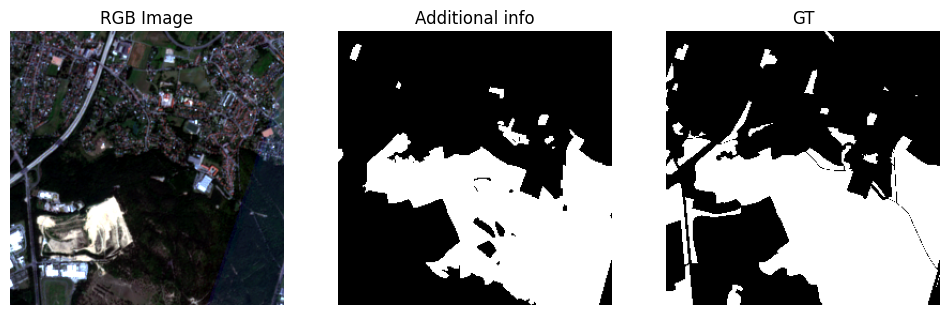

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.49


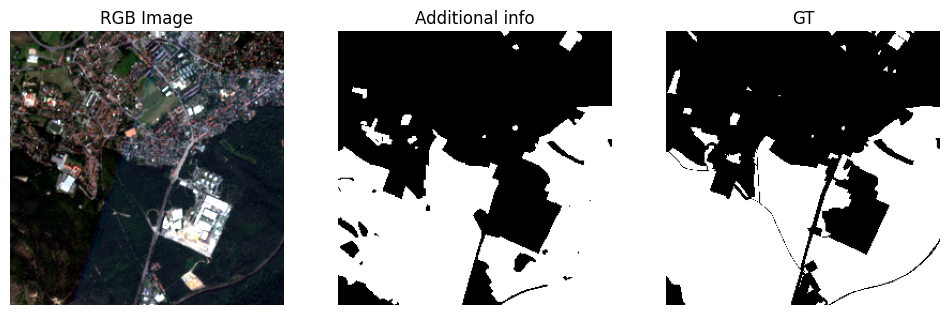

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.71


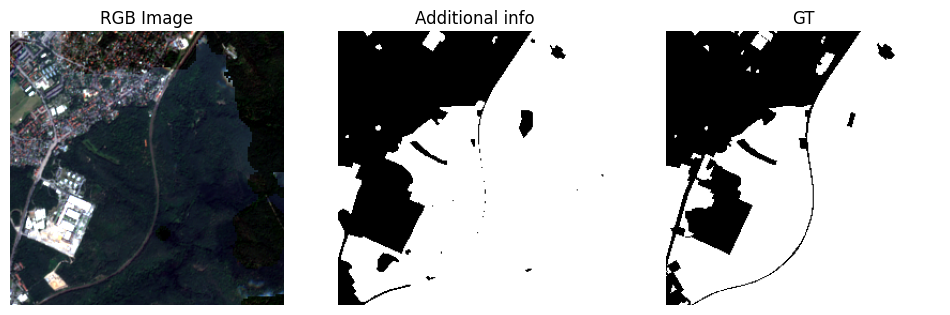

In [12]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(test_loader, 3, "additional", [13])
else:
    visualize_from_torchgeo_dataloader(test_loader, 3, "original")

# 5. Load model from checkpoint

In [13]:
# Direct loading with the correct channel count
model = CustomSegmentationTask.load_from_checkpoint(
    checkpoint_path,
    in_channels=num_channels,  # Match what's in the checkpoint
)

## Plot train loss and val loss

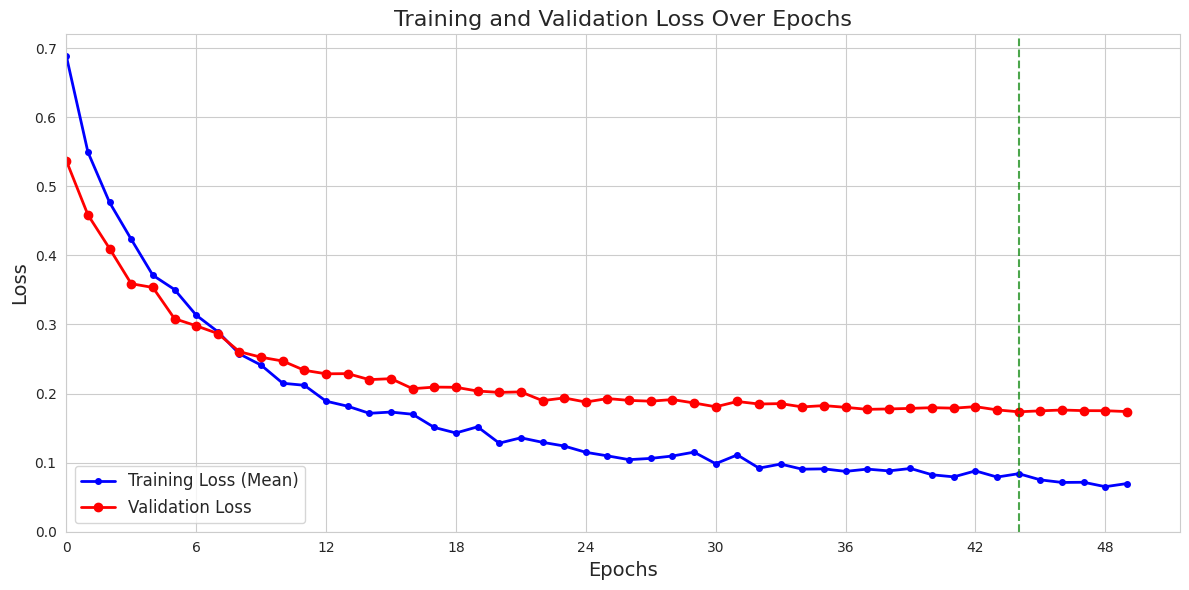

Best model at epoch 44:
  Val Loss: 0.1736
  Val Jaccard: 0.8725


In [14]:
plot_loss_graph(metrics_path, loss_graph_path)

# 6. Evaluate the model

In [15]:
checkpoint_callback = ModelCheckpoint(
    filename="{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=1,  # Save chckpoint with the best validation loss
    # every_n_epochs=5  # Save checkpoint every n epochs
)

In [16]:
early_stopping = EarlyStopping(monitor="val_loss", patience=config["model"]["patience"])

In [17]:
logger = CSVLogger(
    config["paths"]["logger_path"], name=config["paths"]["test_result_folder"]
)

In [18]:
trainer = Trainer(
    max_epochs=config["model"]["epochs"],
    deterministic=True,
    accelerator=config["model"]["accelerator"],
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Visualize prediction on test set

In [19]:
trainer.test(model=model, dataloaders=test_loader, ckpt_path=checkpoint_path)

You are using a CUDA device ('NVIDIA RTX A500 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at ../models/trained_models/version_1/checkpoints/epoch=44-val_loss=0.17.ckpt
/root/pugs_detection/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:362: The dirpath has changed from '../models/trained_models/version_1/checkpoints' to '../models/test_result/version_9/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at ../models/trained_models/v

Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    test_BinaryAccuracy    │    0.9632225036621094     │
│  test_BinaryJaccardIndex  │     0.77772057056427      │
│         test_loss         │    0.3656233549118042     │
└───────────────────────────┴───────────────────────────┘

[{'test_BinaryAccuracy': 0.9632225036621094,
  'test_BinaryJaccardIndex': 0.77772057056427,
  'test_loss': 0.3656233549118042}]

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.793450770994309


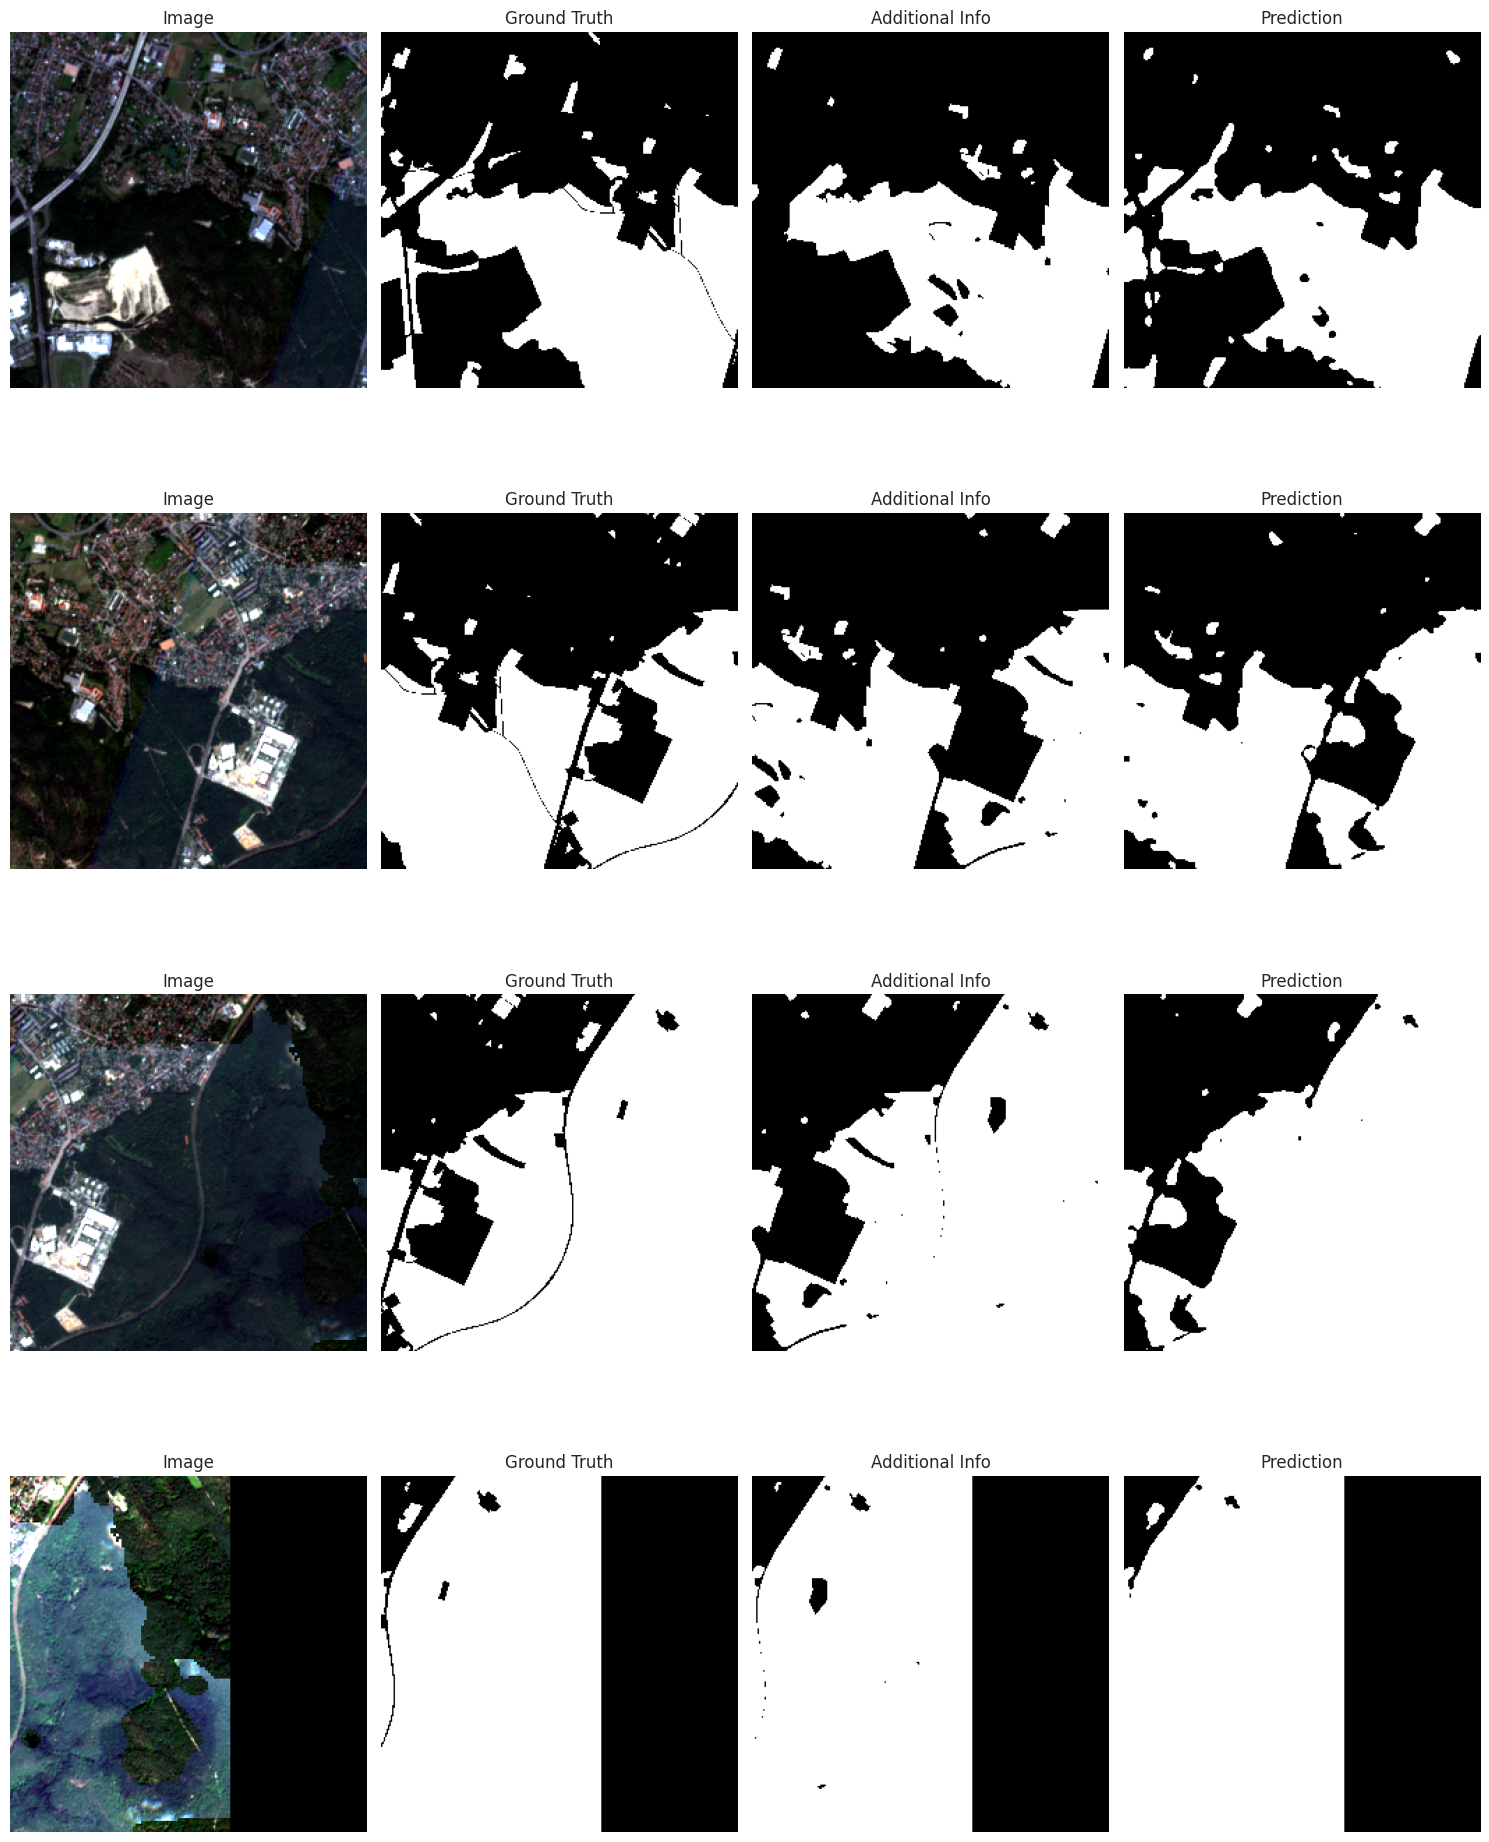

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9967949130492167
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.924619603043794


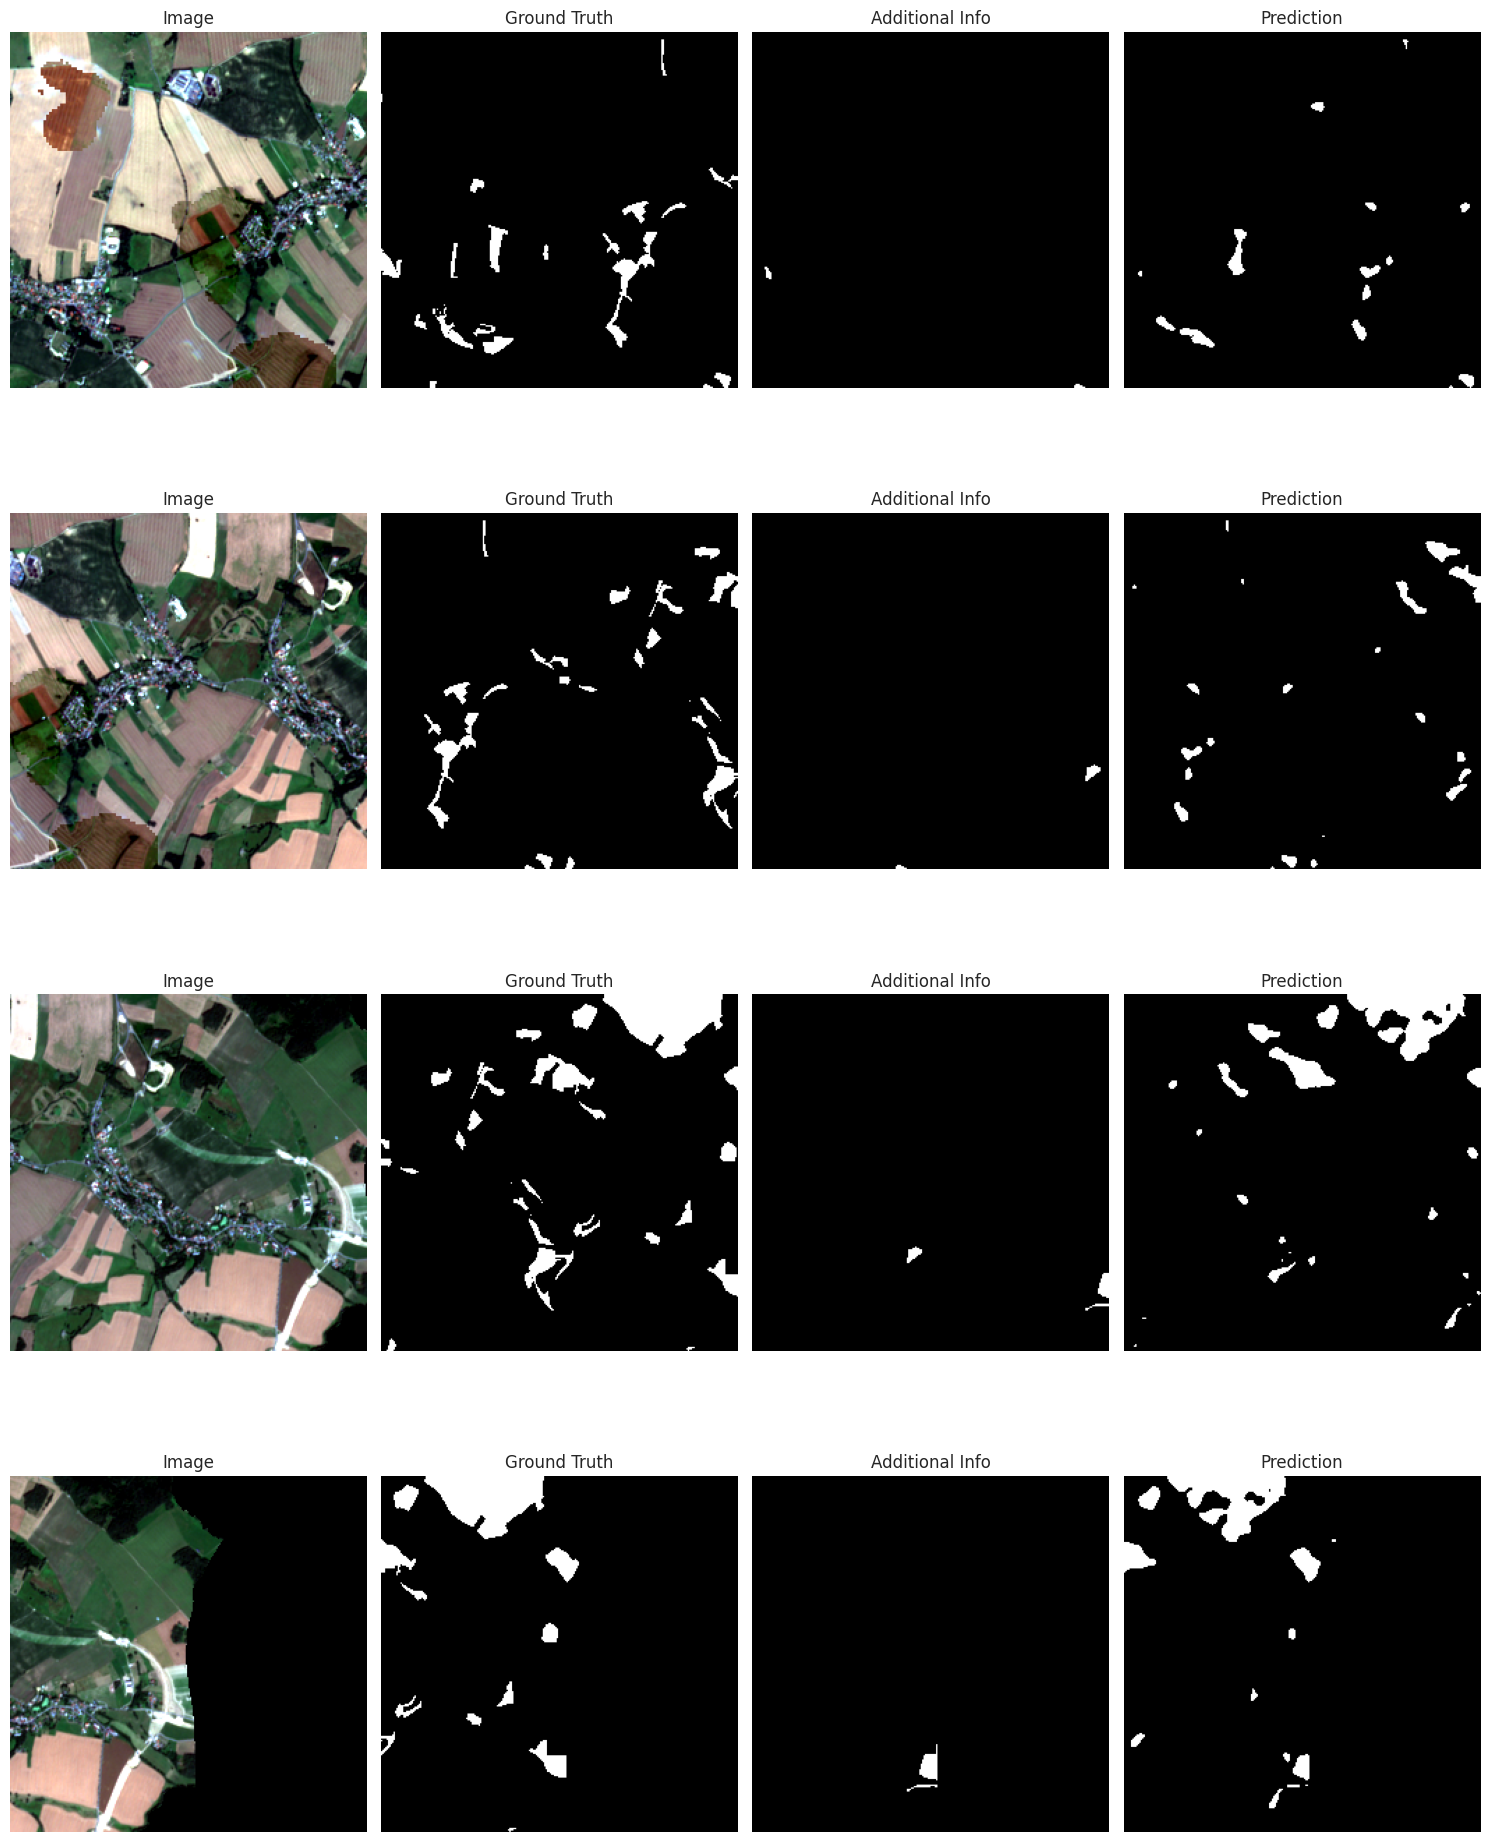

Prediction shape: torch.Size([4, 1, 256, 256])
Mask shape: torch.Size([4, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.8341105729640136
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.8811641432768931
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.8686439502379544
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.7869121704744964


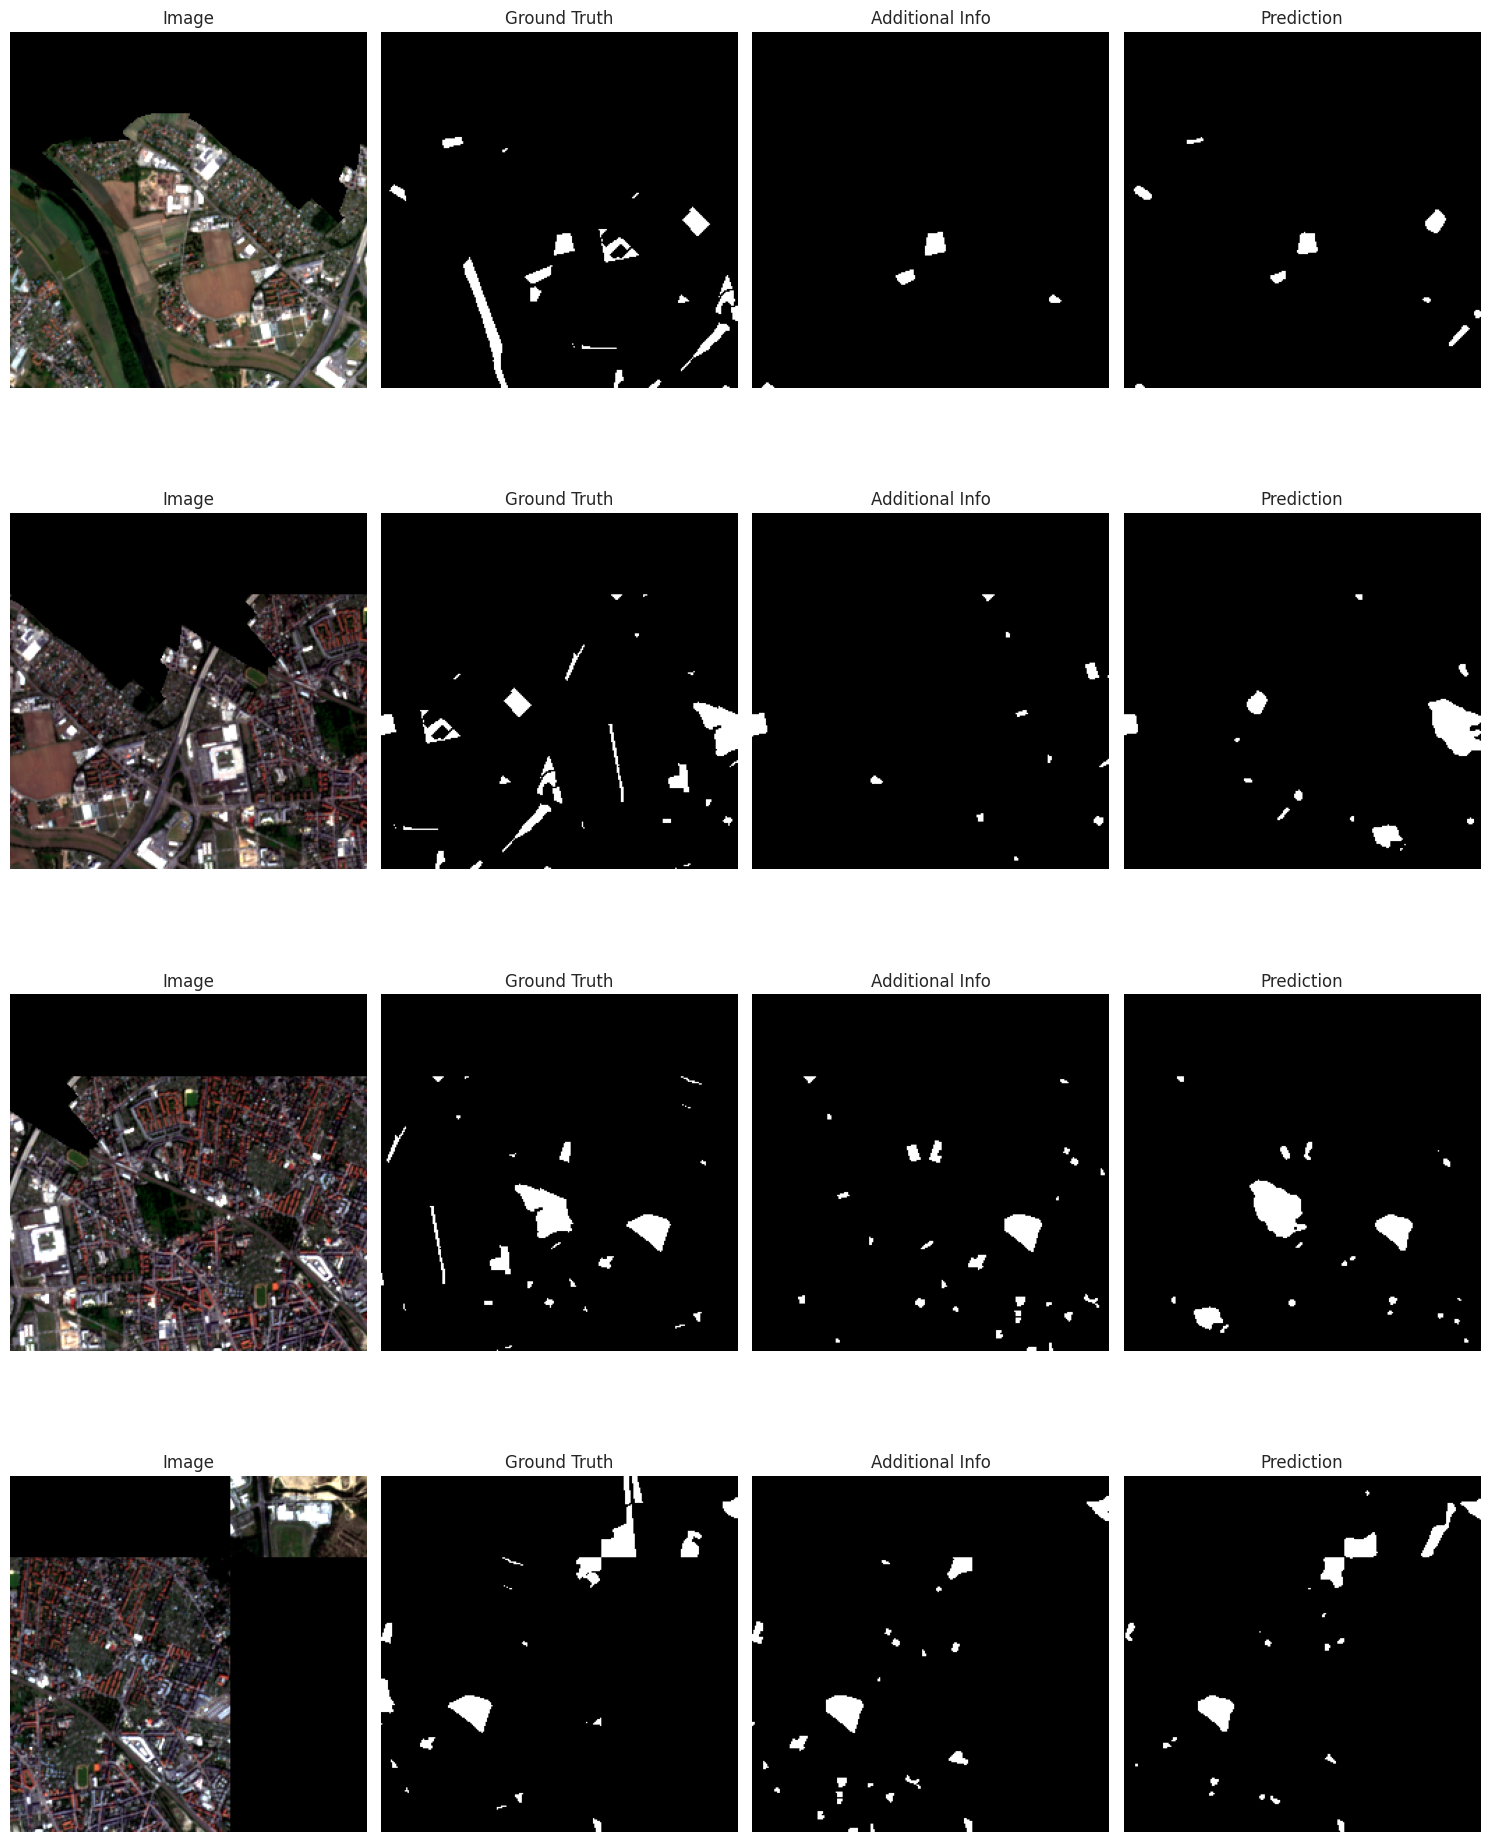

In [20]:
if num_channels > 13:
    visualize_predictions(
        model,
        test_loader,
        mode="additional",
        replace_band_pos=[13],
        output_dir=output_dir,
    )
else:
    visualize_predictions(model, test_loader, mode="original", output_dir=output_dir)

## Confusion matrix

In [21]:
cm = generate_confusion_matrix(model, test_loader)
print("True Negative:", cm[0, 0])
print("False Positive:", cm[0, 1])
print("False Negative:", cm[1, 0])
print("True Positive:", cm[1, 1])

True Negative: 1968931
False Positive: 27563
False Negative: 59206
True Positive: 303596


In [22]:
precision = cm[1, 1] / (cm[1, 1] + cm[0, 1])
recall = cm[1, 1] / (cm[1, 1] + cm[1, 0])
f1 = 2 * precision * recall / (precision + recall)
accuracy = np.sum(np.diag(cm)) / np.sum(cm)
iou = cm[1, 1] / (cm[1, 1] + cm[0, 1] + cm[1, 0])

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"IoU: {iou:.4f}")

Precision: 0.9168
Recall: 0.8368
F1 Score: 0.8750
Accuracy: 0.9632
IoU: 0.7777


In [23]:
metrics = {
    "True Negative": cm[0, 0],
    "False Positive": cm[0, 1],
    "False Negative": cm[1, 0],
    "True Positive": cm[1, 1],
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Accuracy": accuracy,
    "IoU": iou,
}
df = pd.DataFrame([metrics])
df.to_csv(dump_test_metrics_path, index=False)

# 7. Predict whole area

In [24]:
# Use custom collate function to maintain window_ifo as list of tuples
# so we can easily extract the window coordinates
def custom_collate_fn(batch):
    """Keep window coordinates as a list of tuples instead of tensors"""
    images = torch.stack([torch.from_numpy(item["image"]) for item in batch])
    window_infos = [item["window_info"] for item in batch]

    return {"image": images, "window_info": window_infos}

In [25]:
inference_dataset = PredictedImageDataset(
    image_path_whole_area,
    patch_size=256,
    stride=256,
    band_list_predict=band_list_predict,
)

if config["general"]["os"] == "linux":
    inference_loader = DataLoader(
        inference_dataset,
        batch_size=4,
        num_workers=config["model"]["training_num_workers"],
        persistent_workers=True,
        collate_fn=custom_collate_fn,  # Use custom collate function
    )
else:
    inference_loader = DataLoader(
        inference_dataset,
        batch_size=4,
        collate_fn=custom_collate_fn,  # Use custom collate function
    )

In [26]:
prediction_map = predict_whole_area(model, inference_dataset, inference_loader)

100%|██████████| 25/25 [00:20<00:00,  1.20it/s]


In [27]:
os.makedirs(os.path.dirname(prediction_image_path), exist_ok=True)
# Save the prediction
with rasterio.open(
    prediction_image_path,
    "w",
    driver="GTiff",
    height=inference_dataset.height,
    width=inference_dataset.width,
    count=1,
    dtype=rasterio.int16,
    crs=inference_dataset.crs,
    transform=inference_dataset.transform,
) as dst:
    dst.write(prediction_map[np.newaxis, :, :])

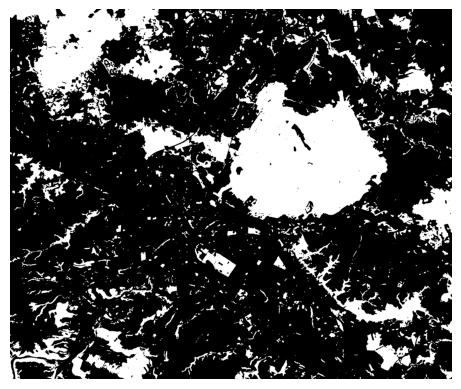

In [28]:
open_image = rasterio.open(prediction_image_path)
image = open_image.read(1)
plt.imshow(image, cmap="gray")
plt.grid(False)
plt.axis("off")
open_image.close()

## Clipped the predicted binary mask to Dresden boundary

In [29]:
dresden_boundary = gpd.read_file(boundary_path)

with rasterio.open(prediction_image_path) as src:
    geoms = [mapping(dresden_boundary.to_crs(src.crs).union_all())]
    out_image, out_transform = mask(src, geoms, crop=True, nodata=-9999)
    out_meta = src.meta.copy()
    out_meta.update(
        {
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": -9999,
        }
    )

os.makedirs(os.path.dirname(clipped_prediction_image_path), exist_ok=True)

with rasterio.open(clipped_prediction_image_path, "w", **out_meta) as dst:
    dst.write(out_image)

(np.float64(-0.5), np.float64(2711.5), np.float64(2263.5), np.float64(-0.5))

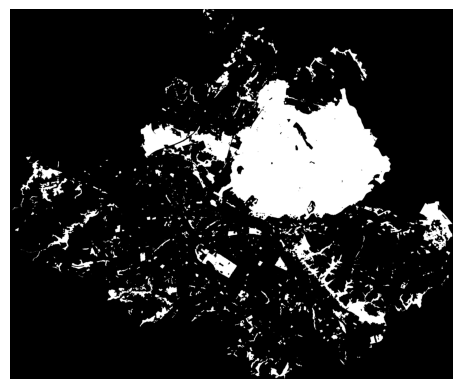

In [30]:
plt.imshow(out_image[0], cmap="gray", vmin=0, vmax=1)
plt.grid(False)
plt.axis("off")

# 8. Save the visualization of prediction and ground truth

In [31]:
viz_coords = [
    (512, 896),
    (512, 1152),
    (768, 1152),
    (896, 1024),
    (896, 1152),
    (896, 1280),
    (1024, 1024),
    (1024, 1280),
    (1024, 1536),
    (1152, 1408),
    (1408, 1280),
    (1536, 1536),
    (1536, 512),
    (1152, 896),
    (896, 1152),
    (512, 1536),
    (1920, 1664),
]

In [32]:
for x, y in tqdm(viz_coords, desc="Generating visualizations", unit="image"):
    try:
        fig = visualize_area(
            original_image_path=clipped_image_path,
            prediction_path=clipped_prediction_image_path,
            ground_truth_path=ground_truth_path,
            x_coord=x,
            y_coord=y,
            window_size=256,
        )

        if output_dir:
            # Save to file
            fig_path = os.path.join(output_dir, f"region_{x}_{y}.png")
            fig.savefig(fig_path, bbox_inches="tight", dpi=300)
            plt.close(fig)
    except Exception as e:
        print(f"Error visualizing window at ({x},{y}): {e}")

print()
print("Complete saving the files")

Generating visualizations: 100%|██████████| 17/17 [00:17<00:00,  1.05s/image]


Complete saving the files


# 9. Save FN and FP maps for visual inspection

Save the false negative (FN) and false positive (FP) map for visual inspection.

In [33]:
save_inference_map(
    clipped_ground_truth_path, clipped_prediction_image_path, "fn", fn_area_path
)
save_inference_map(
    clipped_ground_truth_path, clipped_prediction_image_path, "fp", fp_area_path
)

In [34]:
# Usage example with output directory
# visualize_whole_image(
#     original_image_path=image_path,
#     prediction_path=file_output_path,
#     ground_truth_path='../data/processed/ground truth/dresden_pugs_gt.geotiff',
#     window_size=256,
#     stride=128,  # Larger stride to sample fewer areas
#     output_dir='../reports/visualization/region_samples'
# )